Inventory Risk Segmentation for Warehouse Equipment Monitoring Using Clustering

In [1084]:
import pandas as pd 
import pandasql
from pandasql import sqldf

1️⃣ Business Understanding

2️⃣ SQL Operational Analysis

3️⃣ EDA dengan pandas

4️⃣ Feature selection

5️⃣ Clustering

6️⃣ Insight & Recommendation

1. Import Dataset.

In [1085]:
df = pd.read_csv('logistics_dataset.csv')
df.iloc[:6]

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,117.80,1.14,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,178.80,1.09,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,54.05,0.95,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,31.10,1.90,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,104.97,0.63,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670
5,ITM10005,Apparel,154,62,9,6,35.95,9.47,0.41,L32,...,164.12,0.66,1,0.99,477,7.61,0.95,2024-07-12,180.65,0.803


In [1086]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_id                    3204 non-null   object 
 1   category                   3204 non-null   object 
 2   stock_level                3204 non-null   int64  
 3   reorder_point              3204 non-null   int64  
 4   reorder_frequency_days     3204 non-null   int64  
 5   lead_time_days             3204 non-null   int64  
 6   daily_demand               3204 non-null   float64
 7   demand_std_dev             3204 non-null   float64
 8   item_popularity_score      3204 non-null   float64
 9   storage_location_id        3204 non-null   object 
 10  zone                       3204 non-null   object 
 11  picking_time_seconds       3204 non-null   int64  
 12  handling_cost_per_unit     3204 non-null   float64
 13  unit_price                 3204 non-null   float

In [1087]:
df['last_restock_date'] = pd.to_datetime(df['last_restock_date'])

In [1088]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   item_id                    3204 non-null   object        
 1   category                   3204 non-null   object        
 2   stock_level                3204 non-null   int64         
 3   reorder_point              3204 non-null   int64         
 4   reorder_frequency_days     3204 non-null   int64         
 5   lead_time_days             3204 non-null   int64         
 6   daily_demand               3204 non-null   float64       
 7   demand_std_dev             3204 non-null   float64       
 8   item_popularity_score      3204 non-null   float64       
 9   storage_location_id        3204 non-null   object        
 10  zone                       3204 non-null   object        
 11  picking_time_seconds       3204 non-null   int64         
 12  handli

In [1089]:
df.iloc[:6]

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,117.80,1.14,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,178.80,1.09,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,54.05,0.95,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,31.10,1.90,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,104.97,0.63,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670
5,ITM10005,Apparel,154,62,9,6,35.95,9.47,0.41,L32,...,164.12,0.66,1,0.99,477,7.61,0.95,2024-07-12,180.65,0.803


In [1090]:
df.describe()

,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,picking_time_seconds,handling_cost_per_unit,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score
count,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204.000000,3204,3204.000000,3204.000000
mean,263.491573,54.759363,8.507803,5.578340,25.435868,5.260078,0.542325,95.606429,2.777116,105.887575,1.045993,4.602372,0.849738,521.714732,8.123677,0.600581,2024-07-04 09:30:47.191011328,154.286245,0.601737
min,20.000000,10.000000,3.000000,2.000000,1.010000,0.500000,0.100000,10.000000,0.500000,10.220000,0.100000,0.000000,0.700000,50.000000,1.000000,0.200000,2024-01-01 00:00:00,10.090000,0.259000
25%,144.000000,32.000000,5.000000,4.000000,13.535000,2.917500,0.310000,53.000000,1.660000,59.760000,0.580000,2.000000,0.780000,283.000000,4.590000,0.400000,2024-04-02 00:00:00,83.190000,0.527000
50%,264.000000,55.000000,9.000000,6.000000,25.405000,5.235000,0.540000,96.000000,2.810000,106.005000,1.050000,5.000000,0.850000,513.500000,8.150000,0.600000,2024-07-06 00:00:00,152.870000,0.601000
75%,386.000000,78.000000,12.000000,8.000000,37.412500,7.542500,0.760000,138.000000,3.910000,152.410000,1.522500,7.000000,0.920000,764.250000,11.692500,0.800000,2024-10-07 00:00:00,225.440000,0.677250
max,499.000000,99.000000,14.000000,9.000000,49.980000,10.000000,1.000000,179.000000,5.000000,200.000000,2.000000,9.000000,1.000000,999.000000,15.000000,1.000000,2024-12-30 00:00:00,299.940000,0.936000
std,138.568360,26.053354,3.473229,2.292486,14.038861,2.725639,0.259200,49.218084,1.305213,54.428161,0.550480,2.883708,0.086703,276.768531,4.069191,0.230511,NaN,82.945255,0.108286


In [1091]:
df.isnull().sum()

item_id                      0
category                     0
stock_level                  0
reorder_point                0
reorder_frequency_days       0
lead_time_days               0
daily_demand                 0
demand_std_dev               0
item_popularity_score        0
storage_location_id          0
zone                         0
picking_time_seconds         0
handling_cost_per_unit       0
unit_price                   0
holding_cost_per_unit_day    0
stockout_count_last_month    0
order_fulfillment_rate       0
total_orders_last_month      0
turnover_ratio               0
layout_efficiency_score      0
last_restock_date            0
forecasted_demand_next_7d    0
KPI_score                    0
dtype: int64

In [1092]:
df.duplicated().sum()

np.int64(0)

sqldf(q, globals()) 

Ini adalah bagian paling penting:

- q: Menjalankan teks SQL yang kamu berikan.

- globals() (Kunci Utama): Ini adalah aturan yang sering membingungkan. Fungsi ini memberitahu Python: "Cari nama tabel yang saya tulis di SQL dari semua variabel yang ada di memori Python saya saat ini."

- Contoh: Jika kamu punya variabel berna df_stok di Python, lalu kamu menulis SQL SELECT * FROM df_stok, tanpa globals(), Python tidak akan tahu kalau df_stok yang dimaksud adalah variabel milikmu.


In [1093]:
sql_run = lambda q : sqldf(query=q, env=globals())

"Tiga tanda petik adalah untuk teks yang punya struktur baris baru (newline)." Dan Membuat bisa menulis dalam multiline yaitu bukan yang satu baris panjang tetapi bisa banyak line / baris ke bawah dan dianggap merupakan kesatuan.

Jika kamu memaksakan satu tanda petik tapi menulisnya berbaris-baris (multiline) maka Python akan protes karena satu tanda petik mengharuskan teks selesai di baris yang sama.

Tips Tambahan: Kapan Pakai yang Mana?

- Gunakan ' ' atau " ": Jika query kamu sangat pendek.
Contoh: sql_run("SELECT * FROM orders")

- Gunakan """ """: Jika query kamu sudah melibatkan WHERE, JOIN, atau GROUP BY. Ini akan memudahkan kamu (dan orang lain) saat mengecek jika ada kode yang salah.

-----------------

QUERY LAYER :

🟢 1️⃣ Inventory Risk Monitoring

- Item mana dengan stock_level < reorder_point?

- Berapa jumlah item yang berisiko stockout?

- Category mana dengan total stockout tertinggi?

- Zone mana dengan rata-rata stockout tertinggi?

In [1094]:
df.loc[:, ['stock_level', 'reorder_point']]

,stock_level,reorder_point
0,283,21
1,301,52
2,132,60
3,346,46
4,49,55
...,...,...
3199,343,21
3200,428,43
3201,415,80
3202,173,84


In [1095]:
# Item mana dengan stock_level < reorder_point?

query = """
SELECT
     d.item_id,
     d.stock_level,
     d.reorder_point,
     (d.reorder_point - d.stock_level) AS shortage_gap
FROM df AS d
WHERE d.stock_level < d.reorder_point
ORDER BY shortage_gap DESC -- severity risk
"""
sql_run(query)

,item_id,stock_level,reorder_point,shortage_gap
0,ITM12622,22,99,77
1,ITM12457,25,99,74
2,ITM12039,25,96,71
3,ITM12809,24,91,67
4,ITM10723,22,88,66
...,...,...,...,...
232,ITM10952,48,49,1
233,ITM11120,80,81,1
234,ITM11870,69,70,1
235,ITM12222,77,78,1


C:\Users\m s i\AppData\Local\Temp\ipykernel_24376\4016858610.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


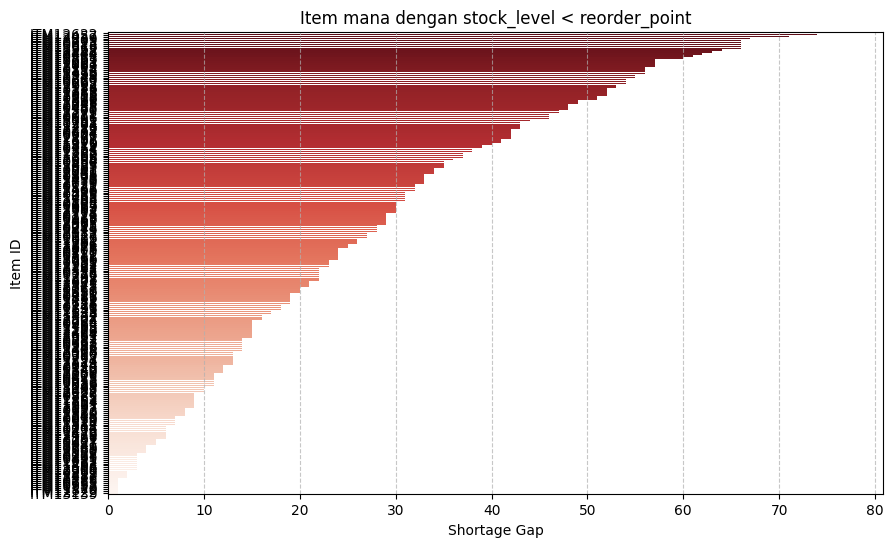

In [1096]:
df_shortage = sql_run(query)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_shortage,
    x='shortage_gap',
    y='item_id',
    palette='Reds_r'
)
plt.title('Item mana dengan stock_level < reorder_point')
plt.xlabel('Shortage Gap')
plt.ylabel('Item ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [1097]:
# Berapa jumlah item yang berisiko stockout?

query = """
WITH risk AS(
    SELECT 
        COUNT(*) AS total_risk_item_stockout
    FROM df AS d 
    WHERE d.stock_level < d.reorder_point),
not_risk AS(
    SELECT
        COUNT(*) AS total_item_safe_from_stockout
    FROM df AS d
    WHERE d.stock_level >= d.reorder_point)
SELECT
    r.total_risk_item_stockout,
    n.total_item_safe_from_stockout
FROM risk AS r 
CROSS JOIN not_risk AS n
"""
sql_run(query)

,total_risk_item_stockout,total_item_safe_from_stockout
0,237,2967


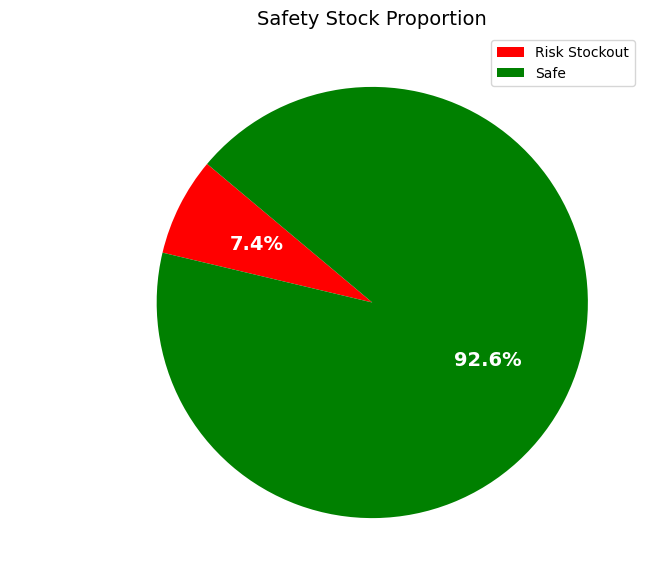

In [1098]:
df_risk = sql_run(query)

labels = ['Risk Stockout', 'Safe']
counts = [df_risk['total_risk_item_stockout'][0], df_risk['total_item_safe_from_stockout'][0]]
colors = ['red', 'green']

plt.figure(figsize=(7, 7))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors,
        textprops={'color':"white", 'fontsize': 14, 'weight':'bold'})
plt.title('Safety Stock Proportion', fontsize=14, color='black')
plt.legend(labels=labels, loc='upper right')
plt.show()

Apa itu autopct?
- Maksudnya: Singkatan dari Automatic Percentage.
- Fungsinya: Memberitahu Python untuk menghitung sendiri persentasenya dan menampilkannya di dalam potongan pie.
Logika Kodenya ('%1.1f%%'):
- %: Awal dari format.
- 1.1f: Tampilkan 1 angka di belakang koma (bilangan desimal/float). Jika ingin tanpa koma, gunakan %1.0f.
- %%: Menampilkan simbol persen % di akhir angka.

Apa itu startangle?
- Maksudnya: Sudut awal pemutaran grafik.
- Fungsinya: Menentukan di mana potongan pertama dimulai. Secara default (0 derajat), potongan dimulai dari arah jam 3 dan berputar berlawanan arah jarum jam.
Aturannya:
- Jika startangle=90, potongan pertama akan dimulai tepat di arah jam 12.
- Jika startangle=140 (seperti kode Anda), posisi awalnya digeser sedikit lagi agar estetika grafik terlihat lebih seimbang.

Logika, Kunci Pemahaman, dan Aturan Main. Bayangkan plt.pie seperti sedang memesan martabak atau pizza:
- counts (Bahan Baku): Data angka yang akan dibagi-bagi.
- labels (Nama): Memberi nama pada setiap potongan.
- colors (Tampilan): Memberi warna pada setiap potongan sesuai urutan data.
- explode (Aksentuasi): Menarik satu potongan keluar agar terlihat lebih menonjol (seperti ditarik dari loyang).
- textprops (Detail Teks): Aturan gaya untuk tulisan yang menempel di grafik.
Aturan Penting:
Urutan dalam counts, labels, dan colors harus sama. Jika data pertama di counts adalah "Risk", maka data pertama di labels harus "Risk Stockout" dan data pertama di colors harus "red".

Logika textprops: Bayangkan textprops (Text Properties) sebagai sebuah folder. Jika Anda ingin mengatur apapun yang berhubungan dengan tulisan (label & angka persen), Anda harus memasukkannya ke dalam folder tersebut menggunakan format Dictionary Python {'kunci': 'nilai'}.

----------------

In [1099]:
# Category mana dengan total stockout tertinggi?

query = """
SELECT
    d.category,
    SUM(d.stockout_count_last_month) AS total_stockout,
    ROUND(AVG(d.stockout_count_last_month),2) AS avg_stockout
FROM df as d
GROUP BY d.category
ORDER BY total_stockout DESC
"""
sql_run(query)

,category,total_stockout,avg_stockout
0,Automotive,3110,4.73
1,Electronics,2985,4.59
2,Pharma,2978,4.51
3,Groceries,2862,4.63
4,Apparel,2811,4.56


C:\Users\m s i\AppData\Local\Temp\ipykernel_24376\1516730160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_category_stockout.sort_values(by='total_stockout', ascending=False),


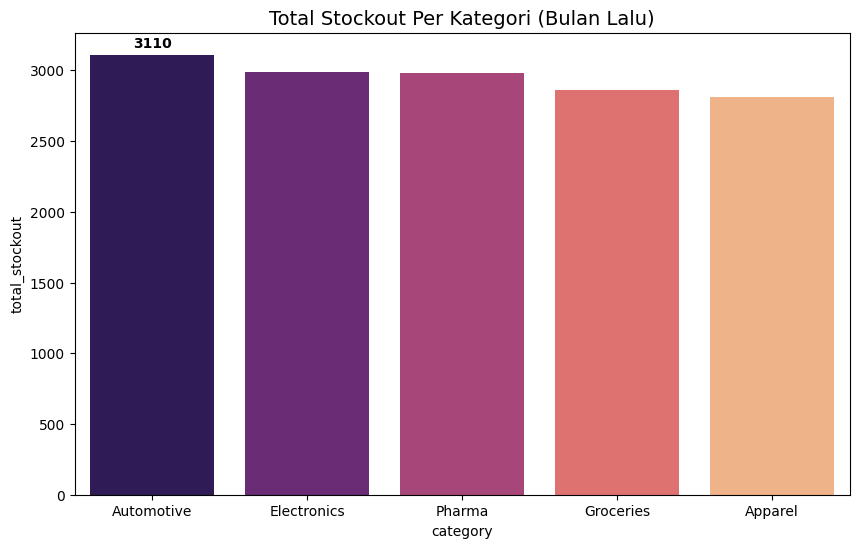

In [1100]:
df_category_stockout = sql_run(query)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_category_stockout.sort_values(by='total_stockout', ascending=False), 
                 x='category',
                 y='total_stockout',
                 palette='magma')
ax.bar_label(ax.containers[0], padding=3, fontweight='bold')
plt.title('Total Stockout Per Kategori (Bulan Lalu)', fontsize=14)
plt.show()

Penjelasan Logika plot Ini:
- ax = sns.barplot(...): Kita memberikan nama ax pada grafik kita. Bayangkan ax adalah "bingkai foto" yang menampung gambar batang-batangnya.
- ax.containers[0]: "Container" adalah istilah teknis untuk kumpulan batang di dalam grafik tersebut. Karena kita hanya punya satu jenis data (total stockout), kita pilih container yang pertama (indeks 0).
- bar_label: Perintah ini otomatis mengambil nilai tinggi batang dan menuliskannya sebagai teks tepat di atasnya.
- padding=3: Ini adalah jarak (spasi) antara ujung batang dengan angka, supaya tidak terlalu menempel.

In [1101]:
# Zone mana dengan rata-rata stockout tertinggi?
query = """
SELECT
    d.zone,
    ROUND(AVG(d.stockout_count_last_month), 2) AS Average_Stockout,
    ROUND(AVG(d.reorder_point), 2) AS Average_Reorder_Point,
    (SELECT
        ROUND(AVG(stockout_count_last_month), 2)
    FROM df) AS Avg_Global_Stock_Level
FROM df AS d
GROUP BY d.zone
ORDER BY Average_Stockout DESC
"""
sql_run(query)


,zone,Average_Stockout,Average_Reorder_Point,Avg_Global_Stock_Level
0,C,4.68,56.26,4.6
1,B,4.63,54.69,4.6
2,D,4.58,53.63,4.6
3,A,4.53,54.55,4.6


🟢 2️⃣ Demand Pressure

- Item dengan daily_demand tertinggi?

- Category dengan rata-rata demand tertinggi?

- Apakah item dengan demand tinggi memiliki stockout lebih tinggi?

In [1102]:
df.columns.to_list()


['item_id',
 'category',
 'stock_level',
 'reorder_point',
 'reorder_frequency_days',
 'lead_time_days',
 'daily_demand',
 'demand_std_dev',
 'item_popularity_score',
 'storage_location_id',
 'zone',
 'picking_time_seconds',
 'handling_cost_per_unit',
 'unit_price',
 'holding_cost_per_unit_day',
 'stockout_count_last_month',
 'order_fulfillment_rate',
 'total_orders_last_month',
 'turnover_ratio',
 'layout_efficiency_score',
 'last_restock_date',
 'forecasted_demand_next_7d',
 'KPI_score']

In [1103]:
# Item dengan daily_demand tertinggi?
query = """
SELECT
    CASE
        WHEN d.daily_demand >= (SELECT AVG(daily_demand) FROM df)
            THEN 'High Demand' 
        ELSE 'Low Demand' 
    END AS Demand_Group,
    ROUND(AVG(d.stockout_count_last_month), 2) AS Avg_Stockout,
    ROUND(AVG(d.daily_demand), 2) AS Avg_Daily_Demand,
    ROUND(AVG(d.stock_level), 2) AS Avg_Stock_Level,
    ROUND(AVG(d.reorder_point), 2) AS Avg_Reorder_Point
FROM df AS d 
GROUP BY Demand_Group
ORDER BY Avg_Stockout DESC
"""   
sql_run(query)

,Demand_Group,Avg_Stockout,Avg_Daily_Demand,Avg_Stock_Level,Avg_Reorder_Point
0,Low Demand,4.63,13.28,267.92,55.24
1,High Demand,4.58,37.62,259.05,54.28


In [1104]:
# Category dengan rata-rata demand tertinggi?
query = """
SELECT
    d.category,
    ROUND(AVG(d.daily_demand), 2) AS Avg_Daily_Demand,
    (SELECT ROUND(AVG(daily_demand), 2) FROM df) AS Global_Daily_Demand,
    (SELECT ROUND(MAX(daily_demand), 2) FROM df) AS Max_Global_Daily_Demand
FROM df AS d
GROUP BY d.category
ORDER BY Avg_Daily_Demand DESC
""" 
sql_run(query)

,category,Avg_Daily_Demand,Global_Daily_Demand,Max_Global_Daily_Demand
0,Automotive,26.00,25.44,49.98
1,Groceries,25.52,25.44,49.98
2,Apparel,25.48,25.44,49.98
3,Pharma,25.47,25.44,49.98
4,Electronics,24.71,25.44,49.98


- Tanpa huruf f, Python menganggap {half_upper} adalah teks biasa (string), bukan variabel. Saat dikirim ke SQL, SQLite bingung melihat karakter { karena itu bukan sintaks SQL yang valid.

- """...""": Hanya string biasa. SQL menerima tulisan: WHERE ... > {half_upper} (Error karena { ilegal di SQL).

- f"""...""": Python akan mencari variabel di dalam kurung kurawal {} dan menggantinya dengan angka sebelum dikirim ke SQL. Jadi SQL akan menerima tulisan: WHERE ... > 5.0 (Berhasil!).

In [1105]:
# Apakah item dengan demand tinggi memiliki stockout lebih tinggi?
half_upper = df['stockout_count_last_month'].quantile(q=0.75)
query = f"""
SELECT
    d.item_id,
    d.daily_demand,
    d.stockout_count_last_month,
    d.reorder_point
FROM df AS d
WHERE d.stockout_count_last_month  > {half_upper}
ORDER BY d.daily_demand DESC
"""
sql_run(query)


,item_id,daily_demand,stockout_count_last_month,reorder_point
0,ITM13191,49.98,9,77
1,ITM10591,49.97,8,84
2,ITM11552,49.96,9,12
3,ITM10929,49.90,9,72
4,ITM11625,49.78,9,88
...,...,...,...,...
676,ITM11973,1.38,8,30
677,ITM10340,1.32,9,73
678,ITM11601,1.30,9,39
679,ITM13087,1.13,8,65


🟢 3️⃣ Cost Pressure

- Item dengan holding_cost_per_unit_day tertinggi?

- Category dengan rata-rata holding cost tertinggi?

- Item dengan turnover_ratio paling rendah?

In [1106]:
df.columns.to_list()

['item_id',
 'category',
 'stock_level',
 'reorder_point',
 'reorder_frequency_days',
 'lead_time_days',
 'daily_demand',
 'demand_std_dev',
 'item_popularity_score',
 'storage_location_id',
 'zone',
 'picking_time_seconds',
 'handling_cost_per_unit',
 'unit_price',
 'holding_cost_per_unit_day',
 'stockout_count_last_month',
 'order_fulfillment_rate',
 'total_orders_last_month',
 'turnover_ratio',
 'layout_efficiency_score',
 'last_restock_date',
 'forecasted_demand_next_7d',
 'KPI_score']

In [1107]:
# Item dengan holding_cost_per_unit_day tertinggi?
value_75 = df['holding_cost_per_unit_day'].quantile(q=0.75)
query = f"""
SELECT
    d.item_id,
    d.holding_cost_per_unit_day AS holding_cost_per_unit_upper_75_percent
FROM df AS d
WHERE d.holding_cost_per_unit_day > {value_75}
ORDER BY d.holding_cost_per_unit_day DESC
""" 
sql_run(query)


,item_id,holding_cost_per_unit_upper_75_percent
0,ITM10172,2.00
1,ITM10436,2.00
2,ITM10583,2.00
3,ITM10602,2.00
4,ITM10919,2.00
...,...,...
796,ITM12475,1.53
797,ITM12526,1.53
798,ITM12778,1.53
799,ITM12962,1.53


In [1108]:
# Item dengan holding_cost_per_unit_day tertinggi?
query = """
SELECT
    d.item_id,
    ROUND(AVG(d.holding_cost_per_unit_day), 2) AS Avg_Holding_Cost
FROM df AS d
GROUP BY d.item_id
ORDER BY Avg_Holding_Cost DESC
""" 
sql_run(query)

,item_id,Avg_Holding_Cost
0,ITM13158,2.0
1,ITM13119,2.0
2,ITM12804,2.0
3,ITM12427,2.0
4,ITM11956,2.0
...,...,...
3199,ITM11553,0.1
3200,ITM11533,0.1
3201,ITM11354,0.1
3202,ITM10568,0.1


In [1109]:
# Category dengan rata-rata holding cost tertinggi?
value_75 =df['holding_cost_per_unit_day'].quantile(0.75)
query = f"""
SELECT
    d.category,
    ROUND(AVG(d.holding_cost_per_unit_day), 2) 
    AS avg_holding_cost_per_unit_day_highest_than_75_percent,
    {value_75} AS holding_cost_above_75
FROM df AS d
WHERE d.holding_cost_per_unit_day  > {value_75}
GROUP BY d.category
ORDER BY avg_holding_cost_per_unit_day_highest_than_75_percent DESC
"""
sql_run(q=query)

,category,avg_holding_cost_per_unit_day_highest_than_75_percent,holding_cost_above_75
0,Electronics,1.77,1.5225
1,Pharma,1.76,1.5225
2,Automotive,1.76,1.5225
3,Apparel,1.76,1.5225
4,Groceries,1.75,1.5225


In [1110]:
# Category dengan rata-rata holding cost tertinggi?
query = """
SELECT
    d.category,
    ROUND(AVG(d.holding_cost_per_unit_day), 2) 
    AS avg_holding_cost_per_unit_day
FROM df AS d
GROUP BY d.category
ORDER BY avg_holding_cost_per_unit_day DESC
"""
sql_run(q=query)

,category,avg_holding_cost_per_unit_day
0,Groceries,1.08
1,Electronics,1.07
2,Apparel,1.04
3,Pharma,1.03
4,Automotive,1.02


Turnover Ratio (Rasio Perputaran Persediaan) adalah metrik yang mengukur seberapa sering stok barang terjual dan digantikan dalam periode tertentu. Sederhananya: Ini adalah skor yang menunjukkan seberapa "laku" atau seberapa cepat barang keluar-masuk dari gudang Anda.

- Item dengan Turnover Tinggi: Biasanya punya holding_cost total yang lebih rendah karena barang tidak lama mengendap di gudang.

- Item dengan Turnover Rendah: Biasanya jadi penyebab holding_cost membengkak karena barang tersebut memakan tempat di rak terlalu lama.

- Terlalu Tinggi: Bisa berbahaya. Artinya stok terlalu tipis, Anda berisiko mengalami stockout (barang habis saat pelanggan ingin beli).

- Rendah yang Terencana: Terkadang dilakukan untuk barang mewah (mobil, perhiasan) atau jika sedang ada diskon besar dari supplier sehingga kita sengaja menumpuk stok.

In [1111]:
# Item dengan turnover_ratio paling rendah?
turn_over_25 = df['turnover_ratio'].quantile(0.25)
holding_cost_75 = df['holding_cost_per_unit_day'].quantile(0.75)
query = f"""
SELECT
    d.item_id,
    d.category,
    d.holding_cost_per_unit_day,
    {holding_cost_75} AS holding_cost_per_unit_day_upper_75,
    d.stock_level,
    d.reorder_point,
    d.turnover_ratio,
    {turn_over_25} AS turn_over_lower_Or_Equal_25
FROM df AS d
WHERE d.turnover_ratio <= {turn_over_25}
    AND d.holding_cost_per_unit_day >= {holding_cost_75}
ORDER BY holding_cost_per_unit_day DESC
"""

sql_run(q=query)

,item_id,category,holding_cost_per_unit_day,holding_cost_per_unit_day_upper_75,stock_level,reorder_point,turnover_ratio,turn_over_lower_Or_Equal_25
0,ITM10172,Apparel,2.00,1.5225,181,60,2.29,4.59
1,ITM10436,Apparel,2.00,1.5225,261,13,1.85,4.59
2,ITM11910,Groceries,2.00,1.5225,357,40,1.42,4.59
3,ITM11956,Pharma,2.00,1.5225,37,89,1.85,4.59
4,ITM10012,Automotive,1.99,1.5225,418,13,4.20,4.59
...,...,...,...,...,...,...,...,...
195,ITM12879,Groceries,1.54,1.5225,125,11,2.92,4.59
196,ITM10373,Groceries,1.53,1.5225,78,58,2.52,4.59
197,ITM11986,Pharma,1.53,1.5225,346,19,4.02,4.59
198,ITM12475,Groceries,1.53,1.5225,165,75,1.74,4.59


🟢 4️⃣ Operational Efficiency

- Zone dengan rata-rata picking_time_seconds tertinggi?

- Apakah layout_efficiency_score rendah berkorelasi dengan picking_time tinggi?

In [1112]:
df.columns.to_list()

['item_id',
 'category',
 'stock_level',
 'reorder_point',
 'reorder_frequency_days',
 'lead_time_days',
 'daily_demand',
 'demand_std_dev',
 'item_popularity_score',
 'storage_location_id',
 'zone',
 'picking_time_seconds',
 'handling_cost_per_unit',
 'unit_price',
 'holding_cost_per_unit_day',
 'stockout_count_last_month',
 'order_fulfillment_rate',
 'total_orders_last_month',
 'turnover_ratio',
 'layout_efficiency_score',
 'last_restock_date',
 'forecasted_demand_next_7d',
 'KPI_score']

In [1113]:
# Zone dengan rata-rata picking_time_seconds tertinggi?
query = """
SELECT
    d.zone,
    ROUND(AVG(d.picking_time_seconds), 2) AS average_picking_time_in_seconds
FROM df AS d 
GROUP BY d.zone 
ORDER BY average_picking_time_in_seconds DESC
"""
sql_run(q=query)


,zone,average_picking_time_in_seconds
0,C,96.73
1,D,96.07
2,B,95.86
3,A,93.81


C:\Users\m s i\AppData\Local\Temp\ipykernel_24376\481067189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


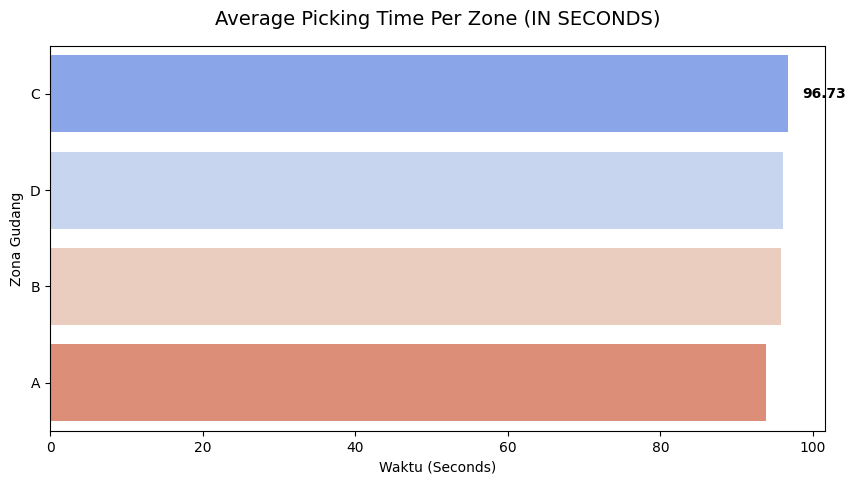

In [1114]:
df_zone_picking = sql_run(query)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_zone_picking,
    x='average_picking_time_in_seconds',
    y='zone',
    palette='coolwarm'
)
ax.bar_label(ax.containers[0], padding=10, fontweight='bold')
plt.title('Average Picking Time Per Zone (IN SECONDS)', fontsize=14, pad=15)
plt.xlabel('Waktu (Seconds)')
plt.ylabel('Zona Gudang')
plt.show()

In [1115]:
# - Apakah layout_efficiency_score rendah berkorelasi dengan picking_time tinggi?
value_75_picking_time = df['picking_time_seconds'].quantile(0.75)
value_25_layout = df['layout_efficiency_score'].quantile(0.25)
query = f"""
SELECT
    dd.zone,
    ROUND(AVG(dd.picking_time_seconds), 2) AS Avg_Picking_Time_In_Seconds_Above_75,
    ROUND(AVG(dd.layout_efficiency_score), 2) AS Avg_Layout_Efficiency_Score_Below_25
FROM (
    SELECT
        d.zone,
        d.picking_time_seconds,
        d.layout_efficiency_score
    FROM df AS d
    WHERE d.picking_time_seconds >= {value_75_picking_time}
        AND d.layout_efficiency_score <= {value_25_layout}) AS dd
GROUP BY dd.zone
ORDER BY Avg_Layout_Efficiency_Score_Below_25 ASC
"""
sql_run(query)

,zone,Avg_Picking_Time_In_Seconds_Above_75,Avg_Layout_Efficiency_Score_Below_25
0,A,159.20,0.28
1,B,161.35,0.30
2,C,158.45,0.30
3,D,157.32,0.31


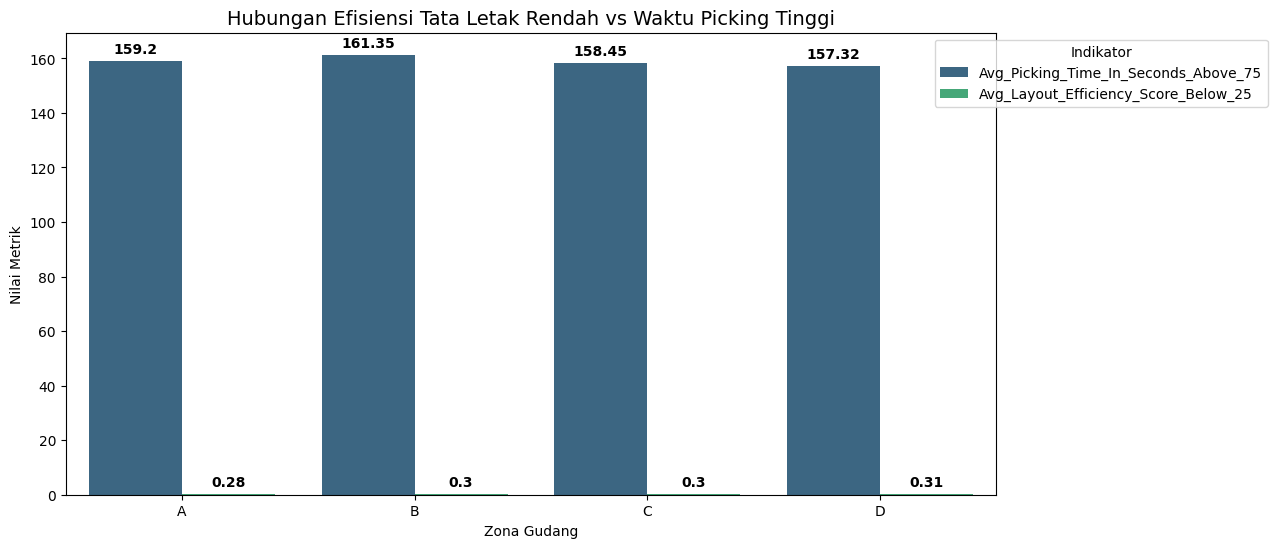

In [1116]:
# 1. Simpan hasil query
df_efficiency = sql_run(query)

# 2. Kita perlu mengubah format data sedikit agar Seaborn mudah membacanya
# Proses ini disebut 'Melt' (merampingkan tabel)
df_melted = df_efficiency.melt(id_vars='zone', 
                               value_vars=['Avg_Picking_Time_In_Seconds_Above_75', 
                                           'Avg_Layout_Efficiency_Score_Below_25'],
                               var_name='Metric', value_name='Value')


plt.figure(figsize=(12, 6))

# 3. Kita gunakan 'hue' untuk membedakan antara Waktu Picking dan Skor Efisiensi
ax = sns.barplot(data=df_melted, x='zone', y='Value', hue='Metric', palette='viridis')

# 4. Tambahkan angka otomatis di atas setiap batang
for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold')

plt.title('Hubungan Efisiensi Tata Letak Rendah vs Waktu Picking Tinggi', fontsize=14)
plt.ylabel('Nilai Metrik')
plt.xlabel('Zona Gudang')
plt.legend(title='Indikator', loc='upper right', bbox_to_anchor=(1.3, 1))

plt.show()

In [1117]:
df_melted

,zone,Metric,Value
0,A,Avg_Picking_Time_In_Seconds_Above_75,159.20
1,B,Avg_Picking_Time_In_Seconds_Above_75,161.35
2,C,Avg_Picking_Time_In_Seconds_Above_75,158.45
3,D,Avg_Picking_Time_In_Seconds_Above_75,157.32
4,A,Avg_Layout_Efficiency_Score_Below_25,0.28
5,B,Avg_Layout_Efficiency_Score_Below_25,0.30
6,C,Avg_Layout_Efficiency_Score_Below_25,0.30
7,D,Avg_Layout_Efficiency_Score_Below_25,0.31


INSIGHT DAN REKOMENDASI :

Melakukan evaluasi ulang formula reorder point dan safety stock dengan memasukkan variabel demand variability (demand_std_dev) dan lead time untuk mengurangi mismatch antara permintaan dan ketersediaan stok. Mengidentifikasi dan mengklasifikasikan item dengan turnover rendah dan holding cost tinggi untuk dilakukan review strategi pengadaan, pengurangan kuantitas pemesanan, atau rasionalisasi SKU. Melakukan analisis slotting ulang (warehouse slotting optimization) dengan memindahkan item high demand ke lokasi dengan akses lebih cepat untuk menurunkan picking time dan meningkatkan efisiensi operasional.

---------------

CLUSTERING WITH K-MEANS

In [1118]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt 

In [1119]:
df.columns.to_list()

['item_id',
 'category',
 'stock_level',
 'reorder_point',
 'reorder_frequency_days',
 'lead_time_days',
 'daily_demand',
 'demand_std_dev',
 'item_popularity_score',
 'storage_location_id',
 'zone',
 'picking_time_seconds',
 'handling_cost_per_unit',
 'unit_price',
 'holding_cost_per_unit_day',
 'stockout_count_last_month',
 'order_fulfillment_rate',
 'total_orders_last_month',
 'turnover_ratio',
 'layout_efficiency_score',
 'last_restock_date',
 'forecasted_demand_next_7d',
 'KPI_score']

In [1120]:
features = df[[
        'daily_demand',
        'demand_std_dev',
        'turnover_ratio',
        'holding_cost_per_unit_day',
        'stockout_count_last_month'
]]

In [1121]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Penggunaan range(1, 10) dalam kode tersebut adalah bagian dari Metode Elbow, sebuah teknik untuk menentukan jumlah kelompok (cluster) yang paling optimal dalam algoritma K-Means.

Berikut adalah logika, kunci pemahaman, dan aturan mainnya:

1. Logika: "Mencari Titik Jenuh"
Bayangkan Anda sedang merapikan gudang (dataset Anda).

- Jika Anda membagi barang hanya ke dalam 1 kategori, isi kategorinya akan sangat berantakan (Inertia/jarak antar data sangat tinggi).

- Jika setiap 1 barang punya kategori sendiri, maka gudang sangat rapi, tapi sistem kategorinya jadi tidak berguna karena terlalu banyak.

Logika range(1, 10) adalah mencoba membagi data secara bertahap: "Bagaimana kalau 1 cluster? Bagaimana kalau 2? ... sampai 9?". Kita ingin melihat di titik mana penambahan cluster sudah tidak lagi memberikan dampak signifikan pada kerapian data.

2. Kunci Pemahaman: Apa itu Inertia?|

- Inertia adalah jumlah kuadrat jarak antara setiap data ke pusat cluster-nya (centroid).

- Semakin kecil Inertia, semakin rapat/homogen isi cluster tersebut.

- Tujuan kita bukan mencari Inertia 0, tapi mencari titik di mana penurunan Inertia mulai melambat (membentuk sudut siku-siku/siku 
lengan).

3. Aturan Main: Kenapa Angka 10?

Sebenarnya angka 10 tidak wajib. Itu adalah aturan praktis (rule of thumb) untuk dataset skala kecil hingga menengah.

- Kenapa mulai dari 1? Karena kita butuh pembanding dasar (baseline) saat data belum dibagi sama sekali.

- Kenapa sampai 10? Karena biasanya untuk data bisnis (seperti kategori produk Anda), membagi lebih dari 10 kelompok seringkali membuat hasil analisis menjadi terlalu rumit untuk diambil tindakan (tidak actionable).

4. Cara Membaca Hasilnya (Titik Elbow)

Saat grafik plt.plot muncul:

- Perhatikan bagian grafik yang menurun tajam lalu tiba-tiba melandai.

- Titik di mana penurunan tajam itu berhenti dan mulai melandai disebut Siku (Elbow).

Aturannya: Pilih angka k pada titik siku tersebut. Itulah jumlah cluster terbaik untuk dataset Anda.

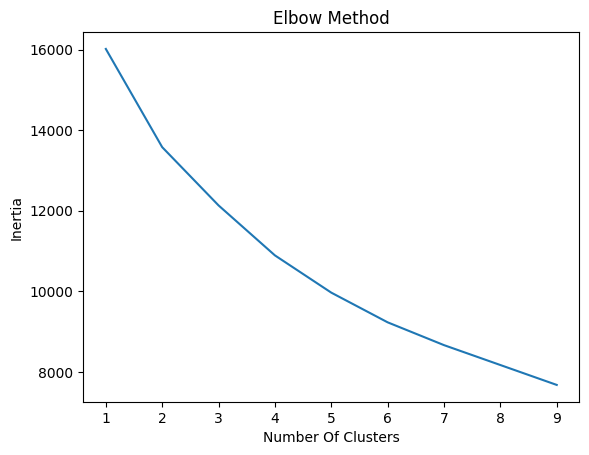

In [1122]:
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel('Number Of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Cluster (k=3): Ini adalah hasil "pengelompokan". Meskipun Anda memasukkan 5 bahan (fitur), Anda meminta komputer membagi data menjadi 3 kelompok besar berdasarkan kesamaan ciri-ciri dari ke-5 bahan tersebut.

- Ini murni untuk penyederhanaan interpretasi bisnis.
Dalam teori Data Science, setelah kita membuat cluster, kita harus memberikan "Nama" atau "Label" pada tiap cluster agar mudah dipahami manajemen.

- Penerapannya: Saat kita mengevaluasi hasil cluster, biasanya ada beberapa variabel yang menjadi "pembeda utama" (paling kontras).

- Logika Aturannya: Saya menyebutkan daily_demand, turnover_ratio, dan stockout karena di industri Warehouse, 3 metrik ini biasanya paling sensitif dan paling mudah dipahami untuk membedakan antara barang yang "sehat" dan "bermasalah". Dua variabel lainnya tetap ikut, tapi biasanya pergerakannya searah dengan variabel utama tersebut.

Teori "The Law of Diminishing Returns": Aturannya adalah memilih titik di mana penambahan cluster baru tidak lagi sebanding dengan usaha manajemen.

- Jika Anda pilih K=2, kelompoknya terlalu umum (hanya Bagus vs Buruk).

- Jika Anda pilih K=3, kelompoknya lebih detail (Bagus, Biasa, Buruk).

- Jika Anda pilih K=4, perbedaannya dengan K=3 sudah mulai tipis.

Untuk Menentukan "nama" atau "label" untuk sebuah cluster memang bukan tebak-tebakan, melainkan ada metodologi teknisnya.
Berikut adalah panduan langkah demi langkah, logika, dan aturan untuk memberikan label cluster secara logis dan ilmiah: 

1. Logika Utama: "Analisis Profiling" (Membandingkan Rata-Rata)
Setelah Anda menjalankan K-Means dengan 5 variabel, Anda WAJIB menghitung nilai rata-rata tiap variabel untuk setiap cluster. Inilah "kunci jawaban" untuk memberikan label. Aturan Mainnya: Bandingkan nilai rata-rata Cluster A, B, dan C. Mana yang paling tinggi dan mana yang paling rendah?

- Contoh Simulasi Logis (Penerapan)
Misalkan Anda memilih 3 Cluster dengan 5 Variabel Anda. Setelah dihitung rata-ratanya

2. Cara Memberi Label Secara Tepat (Kunci Pemahaman)
Dari data di atas, kita gunakan Logika Eliminasi dan Dominasi. 

3. Teori dan Aturan Penamaan (Profiling)

Ada 3 teknik dalam teori Data Science untuk menamai cluster:

- Metode Ekstrem: Cari variabel yang nilainya paling mencolok (paling tinggi/rendah) dibanding cluster lain. (Contoh: "High Holding Cost Items").

- Metode Konteks Bisnis: Hubungkan dengan istilah industri. Di gudang, istilahnya adalah ABC Analysis (A=Laku, B=Biasa, C=Tidak Laku).

- Metode Karakteristik: Menggabungkan dua variabel dominan. (Contoh: "Low Demand - High Cost").



In [1123]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

In [1124]:
df.iloc[:6]

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score,Cluster
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,1.14,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556,1
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,1.09,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723,2
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,0.95,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680,1
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,1.90,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488,1
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,0.63,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670,1
5,ITM10005,Apparel,154,62,9,6,35.95,9.47,0.41,L32,...,0.66,1,0.99,477,7.61,0.95,2024-07-12,180.65,0.803,0


In [1125]:
cluster_profile = df.groupby('Cluster')[['daily_demand', 'demand_std_dev', 'turnover_ratio', 
    'holding_cost_per_unit_day', 'stockout_count_last_month']].mean().reset_index()
cluster_profile

,Cluster,daily_demand,demand_std_dev,turnover_ratio,holding_cost_per_unit_day,stockout_count_last_month
0,0,23.022023,8.168802,8.431136,1.020142,4.156167
1,1,39.557464,4.044150,7.960663,1.101979,4.625360
2,2,13.871988,3.317654,7.953012,1.017857,5.064672


Sesuai dengan kode yang kamu tulis, hasilnya sudah otomatis menjadi DataFrame. Di dalam Pandas, hasil dari fungsi .groupby().mean() secara teknis adalah objek DataFrame.


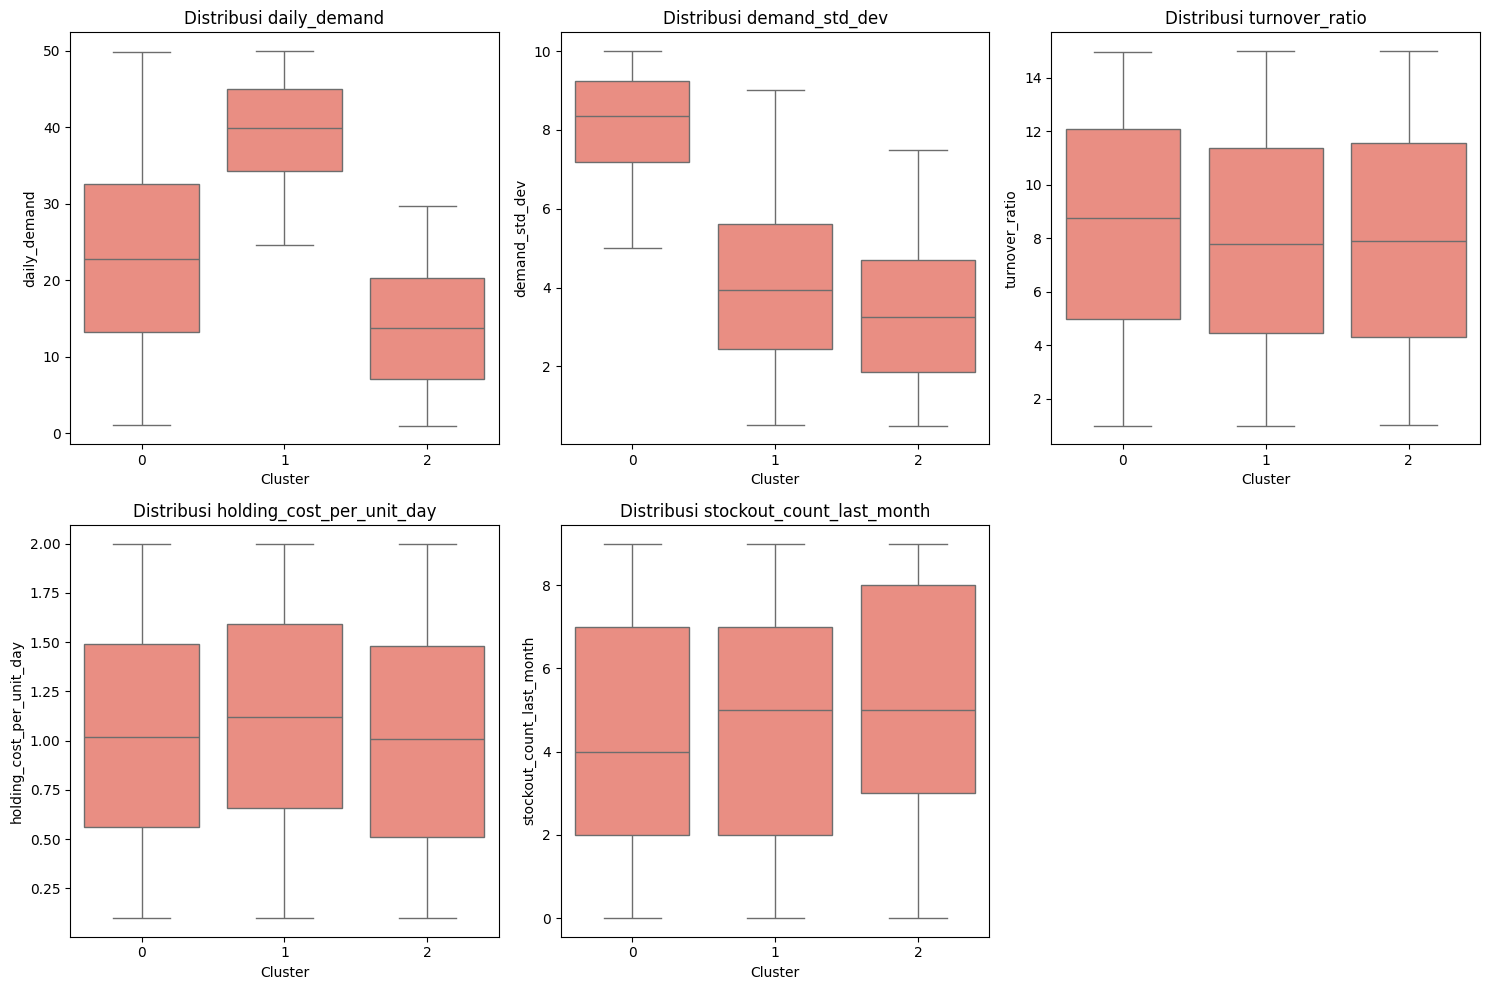

In [1126]:
import seaborn as sns 
import matplotlib.pyplot as plt 

features_list = ['daily_demand', 'demand_std_dev', 'turnover_ratio', 
                 'holding_cost_per_unit_day', 'stockout_count_last_month']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_list):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Cluster', y=col, data=df, color='salmon')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

- Python (Looping): Fungsi enumerate() memulai hitungan indeks (i) dari 0. Jadi, untuk 5 fitur, nilai i adalah: 0, 1, 2, 3, 4.

- Matplotlib (Subplot): Fungsi plt.subplot(baris, kolom, nomor_plot) mewajibkan nomor plot dimulai dari 1. Matplotlib tidak mengenal "Plot ke-0".

Maka rumusnya adalah i + 1:

- Saat loop pertama (i = 0), kita butuh plot ke-1.

- Saat loop kedua (i = 1), kita butuh plot ke-2, dan seterusnya.

In [1127]:
df['Cluster'].value_counts().reset_index()

,Cluster,count
0,0,1127
1,1,1041
2,2,1036


🧠 1️⃣ Bagaimana Menginterpretasikan Distribusi Ini?

Artinya:

- ✅ Model tidak bias ke satu cluster

- ✅ Tidak ada cluster kecil yang hanya berisi outlier

- ✅ Segmentasi cukup stabil dan alami

Kalau misalnya hasilnya:

- Cluster 0: 3000

- Cluster 1: 150

- Cluster 2: 50

Itu tanda cluster mungkin tidak meaningful. Tapi Hasil Tersebut Relatif seimbang.

In [1128]:
label = df['Cluster']
score = silhouette_score(X=scaled_features, labels=label)

print(f"Silhoutte Score (Kmeans k=3): {score:.2f}")

Silhoutte Score (Kmeans k=3): 0.14


| Score       | Interpretasi            |
| ----------- | ----------------------- |
| 0.70 – 1.00 | Cluster sangat kuat 🔥  |
| 0.50 – 0.69 | Cukup bagus             |
| 0.25 – 0.49 | Lemah tapi masih usable |
| 0.00 – 0.24 | Sangat lemah            |
| < 0         | Salah clustering        |

0.14, Artinya:

👉 Cluster terbentuk lemah

👉 Antar cluster tidak terlalu terpisah jelas

👉 Banyak titik yang jaraknya hampir sama ke cluster lain

Tapi ini bukan berarti gagal total.

🧠 2️⃣ Kenapa Bisa Rendah?

Biasanya karena:

- Data memang tidak punya struktur cluster alami

- Fitur kurang representatif

- Terlalu banyak noise

- Nilai antar kelompok overlap besar

- K yang dipilih kurang optimal

Dan yang paling penting:

- Silhouette score di business data sering memang rendah.

- Inventory / sales data sering tidak clean terpisah seperti textbook dataset.

"The silhouette score indicates weak separation, which is common in real-world inventory data due to overlapping demand behavior. However, from a business perspective, the clusters still show meaningful differences in sales velocity and stock turnover, making them useful for operational decision-making."

In [1129]:
df['Cluster'].replace({0:'High Volume Volatile Goods',
                      1: 'Stable Revenue Drivers',
                      2: 'Under Stocked Low Demand'}, inplace=True)

1. Cluster 1: "The Reliable Stars" (Bukan High Risk)
sebenarnya ini adalah Cluster terbaik.
- Logika: Lihat daily_demand-nya, ini yang paling tinggi dan sangat stabil (demand_std_dev rendah).
- Kunci Pemahaman: Barang yang demand-nya tinggi dan stabil adalah "mimpi indah" manajer gudang karena sangat mudah diprediksi kapan harus pesan lagi.
- Kenapa Holding Cost Tinggi? Biasanya karena barangnya bernilai tinggi atau jumlah stok yang disimpan sengaja banyak untuk mendukung demand yang besar itu. Label: High Value, High Demand (Premium Items).

2. Cluster 0: "The Volatile Fast-Movers"
Analisis Ini Adalah fast moving sudah tepat karena turnover_ratio-nya paling tinggi secara rata-rata.
- Logika: Meskipun demand-nya di bawah Cluster 1, tapi demand_std_dev-nya paling tinggi.
- Kunci Pemahaman: Ini adalah barang yang "laku banget tapi musiman/berantakan". Kadang laku keras, kadang tidak. Ini justru yang High Risk untuk operasional karena sulit diprediksi (volatile).
- Label: High Turnover, High Volatility (Fast Moving but Unpredictable).

3. Cluster 2: "The Neglected Items" (Masalah Terbesar)
Sebenarnya ini adalah cluster yang paling bermasalah.
- Logika: daily_demand paling rendah, tapi stockout_count_last_month justru paling tinggi.
- Kunci Pemahaman: Ini aneh. Permintaan sedikit, tapi kok sering kehabisan stok? Artinya, manajemen stok untuk barang-barang ini sangat buruk atau diabaikan oleh tim pengadaan.
- Label: Low Demand, Poor Availability (Underperformers).

Kenapa Stockout Secara Keseluruhan Rendah? kenapa stockout terlihat rendah di semua cluster (rata-rata di angka 4-5 kali). Dalam data science, ini bisa berarti dua hal:
- Operasional Bagus: Secara umum gudang kamu memang jarang bocor stoknya.
- Skala Data: Jika angka 5 itu adalah dalam hitungan hari per bulan, maka 5 hari kosong dari 30 hari sebenarnya sudah cukup parah (16% waktu barang tidak ada).


STATISTICAL HYPOTEST TESTING :

T-Test

H0:

Rata-rata stockout sama antara dua kelompok.

H1:

Item di bawah reorder point memiliki stockout lebih tinggi.

In [1130]:
from scipy.stats import levene
from scipy.stats import ttest_ind


In [1131]:
below = df[df['stock_level'] < df['reorder_point']]['stockout_count_last_month'] # Hypotheses Null
above = df[df['stock_level'] >= df['reorder_point']]['stockout_count_last_month'] # Hypothese Alternative

stat_lev, p_lev = levene(below, above)

print(f"Levene Test Value : {p_lev}")



Levene Test Value : 0.4077556553048667


In [1132]:
if p_lev > 0.05:
    print("Hasil-Nya Ialah Equal Variance")
    equal_variance = True
else:
    print("Hasil-nya Variance Is Not Equal")
    equal_variance = False

Hasil-Nya Ialah Equal Variance


In [1133]:
from scipy.stats import shapiro

In [1134]:
stat_below, pvalue_below = shapiro(below)
stat_above, pvalue_above = shapiro(above)
alpha = 0.05

if pvalue_below > alpha and pvalue_above > alpha:
    print(f"Data Distribution Is Normal : {pvalue_below:.2f} p-value, {pvalue_above:.2f} p-value")
else:
    print(f"Data Distribution Is Not Normal : {pvalue_below:.2f} p-value, {pvalue_above:.2f} p-value (So Using Mann-Withey Instead)")

Data Distribution Is Not Normal : 0.00 p-value, 0.00 p-value (So Using Mann-Withey Instead)


Pilih Mann-Whitney U: Jika jumlah data kamu sedikit atau sedang (misal < 500 baris) dan distribusinya miring. Ini adalah jalur paling aman.

Pilih Z-Test: Hanya jika sampel kamu sangat besar (misal > 30 atau > 100 tergantung literatur)

Keputusan: Karena data stockout_count kamu tidak normal, Mann-Whitney adalah hasil yang paling valid dan paling sulit didebat.

Kelemahan Shapiro-Wilk (Kunci Pemahaman)

Shapiro-Wilk punya batasan:
- Terlalu Sensitif pada Sampel Besar: Jika data kamu ada 5.000 baris, sedikit saja ada pencilan (outlier), 
- Shapiro-Wilk akan langsung bilang "Tidak Normal" (p < 0.05), padahal secara visual mungkin datanya cukup oke.
- Batas Maksimal: Biasanya hanya efektif untuk N < 5000. Jika data lebih besar, orang beralih ke uji Kolmogorov-Smirnov atau melihat Visual (QQ-Plot).


In [1135]:
from scipy.stats import ttest_ind
stat, p_value = ttest_ind(below, above, equal_var=equal_variance)
if p_value > 0.05:
    print(f"Stockout Mean Between Two Group Is Not Significant Difference : {p_value:.2f}")
else:
    print(f"The Mean Stockout Between Two Group Is Significant Difference {p_value:.2f}")


Stockout Mean Between Two Group Is Not Significant Difference : 0.88


Z-Test

H0:

Rata-rata stockout sama antara dua kelompok.

H1:

Item di bawah reorder point memiliki stockout lebih tinggi.

In [1136]:
from statsmodels.stats.weightstats import ztest

In [1137]:
stat_z, zP_value = ztest(below, above)
if zP_value > 0.05:
    print(f"The Mean Between Two Group Is Not Significant Difference : {zP_value:.2f}")
else:
    print(f"The Mean Between Two Group Is Significant Difference : {zP_value:.2f}")

The Mean Between Two Group Is Not Significant Difference : 0.88


U-MannWhitney-Test

H0:

Rata-rata stockout sama antara dua kelompok.

H1:

Item di bawah reorder point memiliki stockout lebih tinggi.

In [1138]:
from scipy.stats import mannwhitneyu

In [1139]:
stat_mw, p_mw =mannwhitneyu(below, above)
if p_mw > 0.05:
    print(f"Hypotheses Null Is Significant And Cannot Reject It : {p_mw:.2f}")
else:
    print(f"Hypotheses Alternative Is Significant And Cannot Reject It : {p_mw:.2f}")


Hypotheses Null Is Significant And Cannot Reject It : 0.87


ANNOVA

Hipotesis:

Apakah rata-rata daily_demand berbeda antar category?

In [1140]:
from scipy.stats import f_oneway

groups = [group['daily_demand'].values for name, group in df.groupby('category')]
stat, p_value = f_oneway(*groups)

if p_value > 0.05:
    print(f"The Mean Between Group Is Not Significant Difference : {p_value:.2f}")
else:
    print(f"The Mean Between Group Is Significant Difference : {p_value:.2f}")


The Mean Between Group Is Not Significant Difference : 0.59


Independensi (Asumsi ANOVA/T-test):
- Logika: Apakah nilai satu baris data mempengaruhi baris lainnya? Dalam datasetmu, jika satu barang (item_id) tidak ada hubungannya dengan barang lain (bukan barang yang sama yang dicatat dua kali), maka asumsi ini terpenuhi.
- Kunci Pemahaman: Ini lebih ke arah desain data, bukan hitungan statistik.
Multikolinieritas:
- Logika: Apakah ada dua atau lebih kolom (variabel independen) yang "bercerita tentang hal yang sama"? Contoh: unit_price dan holding_cost mungkin sangat berhubungan. Jika terlalu berhubungan, model akan bingung menentukan mana yang benar-benar berpengaruh.
- Kunci Pemahaman: Ini hanya perlu dicek jika kamu ingin membuat Model Regresi (prediksi angka) atau Klasifikasi. Untuk ANOVA sederhana (membandingkan kategori), kamu tidak perlu cek multikolinieritas.

ANOVA: Gunakan hanya jika data Normal dan Varians Sama.

Kruskal-Wallis: Gunakan jika data Tidak Normal (hasil Shapiro < 0.05)

In [1141]:
from scipy.stats import kruskal
stats_kw, pvalue_kw = kruskal(*groups)
if pvalue_kw > 0.05:
    print(f"The Mean Between Group Is Not Significant Difference : {pvalue_kw:.2f}")
else:
    print(f"The Mean Between Group Is Significant Difference : {pvalue_kw:.2f}")

The Mean Between Group Is Not Significant Difference : 0.59


Kenapa harus pakai *groups? (Logika Unpacking) :

- Dalam Python, tanda bintang (*) disebut sebagai Argument Unpacking Operator.
- Tanpa Bintang (groups): Kamu mengirim satu buah "wadah" (list) yang berisi banyak grup. Fungsi kruskal akan bingung karena dia mengira kamu hanya memasukkan satu kelompok data.
- Dengan Bintang (*groups): Kamu membongkar wadah tersebut dan mengeluarkan isinya satu per satu sebagai argumen terpisah.
- Analogi: Bayangkan kamu punya kotak berisi 5 bola. Jika kamu memberikan kotaknya ke teman, dia hanya menerima 1 barang (kotak). Jika kamu "unpack" (*), kamu memberikan 5 bola sekaligus ke tangannya.

Aturan Emas (Kapan Harus Pakai?) Hanya jika p <= 0.05.

- Jika hasil Kruskal-Wallis kamu adalah 0.59 (seperti sebelumnya), kamu dilarang keras melakukan Post-hoc. Melakukannya hanya akan membuang waktu dan meningkatkan risiko kesalahan statistik.
- Koreksi Alpha: Saat membandingkan banyak pasangan, risiko "kebetulan" ( Type I Error
) meningkat. Uji Post-hoc biasanya menggunakan koreksi (seperti Bonferroni) untuk menjaga agar kesimpulannya tetap jujur.

CHI-SQUARE

Hipotesis:

Apakah zone berpengaruh terhadap risiko stockout tinggi?

In [1142]:
df['High_Stockout'] = df['stockout_count_last_month'] >= df['stockout_count_last_month'].quantile(0.75)


In [1143]:
df.iloc[:6]

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score,Cluster,High_Stockout
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556,Stable Revenue Drivers,False
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723,Under Stocked Low Demand,False
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680,Stable Revenue Drivers,True
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488,Stable Revenue Drivers,False
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670,Stable Revenue Drivers,False
5,ITM10005,Apparel,154,62,9,6,35.95,9.47,0.41,L32,...,1,0.99,477,7.61,0.95,2024-07-12,180.65,0.803,High Volume Volatile Goods,False


In [1144]:
from scipy.stats import chi2_contingency

In [1145]:
table = pd.crosstab(index=df['zone'], columns=df['High_Stockout'])
table

High_Stockout,False,True
zone,,
A,545,267
B,546,238
C,522,253
D,587,246


In [1146]:
chi2, p, dof, expected = chi2_contingency(table)
if p > 0.05:
    print(f"Zone Is Not Significant Associated To HighStock | Chi-Square P-Value : {p:.2f}")
else:
    print(f"Zone Is Significant Associated To HighStock | Chi-Square P-Value : {p:.2f}")

Zone Is Not Significant Associated To HighStock | Chi-Square P-Value : 0.37


Kamu menggunakan chi2_contingency untuk melihat hubungan antara dua variabel kategori (zone dan High_Stockout), yang mana memang merupakan kegunaan utama dari Chi-Square Test of Independence.

Logika Dasar: "Apakah Ada Pola atau Cuma Kebetulan?"
Chi-Square tidak melihat rata-rata, tapi melihat frekuensi (jumlah kejadian).
- Pertanyaan Inti: "Apakah kemunculan High Stockout terdistribusi merata di semua Zone, atau apakah ada Zone tertentu yang 'langganan' kena High Stockout?"
- Expected vs Observed: Chi-Square membandingkan jumlah yang sebenarnya terjadi (Observed) dengan jumlah yang seharusnya terjadi jika tidak ada hubungan sama sekali (Expected). Jika selisihnya besar, maka p-value akan value akan kecil (< 0.05).

Aturan Main (Syarat Sah Chi-Square). Ada satu aturan "keramat" dalam Chi-Square yang sering dilupakan:
1. Independensi: Satu barang hanya boleh masuk ke satu sel di tabel (sudah terpenuhi).
2. Ukuran Sampel (The Rule of 5): Nilai frekuensi harapan (Expected Value) di setiap sel tidak boleh kurang dari 5.
- Kenapa? Jika sampel terlalu sedikit (misal Zone C hanya punya 2 barang), hasil Chi-Square menjadi tidak stabil dan tidak akurat.
- Solusi jika tidak terpenuhi: Jika data kamu sedikit, gunakan Fisher’s Exact Test sebagai gantinya.

Interpretasi Hasil Kamu

- p > 0.05 : Berarti lokasi gudang (zone) tidak ada hubungannya dengan tingkat stockout. Masalah stockout terjadi secara acak atau merata di seluruh gudang.

- p <= 0.05 : Berarti ada masalah di zone tertentu. Kamu perlu melihat tabel crosstab lagi untuk mencari tahu zone mana yang kontribusi High Stockout-nya paling menyimpang. High_Stockout biasanya adalah variabel buatan (binari), pastikan mendefinisikan "High" dengan ambang batas yang masuk akal (misal: di atas rata-rata atau di atas kuartil 3).

In [1147]:
from scipy.stats import fisher_exact

Result = []

for z in table.index:
    target = table.loc[z].values 
    others = table.drop(z).sum().values
    odds_ratio, p_val = fisher_exact([target, others])
    Result.append({
        'Zone': z, 
        'Odds_Ratio': round(odds_ratio, 2),
        'P_Value': round(p_val, 2)
    })

df_odds = pd.DataFrame(Result).sort_values(by='Odds_Ratio', ascending=False)
df_odds

,Zone,Odds_Ratio,P_Value
3,D,1.12,0.21
1,B,1.06,0.51
2,C,0.92,0.37
0,A,0.91,0.27


Logika & Kunci Pemahaman : Dalam statistik, Chi-Square adalah tes "pintu masuk".
- Chi-Square (p=0.37): Mengatakan bahwa secara keseluruhan, tidak ada bukti kuat bahwa Zone mempengaruhi High_Stockout. Perbedaan angka yang kamu lihat kemungkinan besar hanya kebetulan (noise).
- Odds Ratio: Tetap bisa dihitung, tapi fungsinya sekarang hanya sebagai estimasi besarnya kecenderungan, bukan sebuah kepastian statistik.
Cara Menginterpretasikan Hasil. Mari kita ambil contoh baris pertama hasilmu (Zone D, OR: 1.12, p: 0.21):
- Interpretasi: Barang di Zone D memiliki kecenderungan 1.12 kali lebih besar (atau 12% lebih tinggi) untuk mengalami High Stockout dibandingkan gabungan zone lainnya (A, B, dan C).
- Validitas: Namun, karena P-Value (0.21) > 0.05, maka angka 1.12 ini TIDAK signifikan secara statistik. Artinya, di lapangan, risiko di Zone D sebenarnya dianggap hampir sama saja dengan zone lainnya.
- Sebutkan bahwa Chi-Square (0.37) menunjukkan tidak ada hubungan signifikan antara lokasi simpan (Zone) dengan tingkat stok habis.
- Sebutkan bahwa meskipun Zone D memiliki Odds Ratio tertinggi (1.12), angka ini tidak cukup kuat untuk dijadikan dasar perubahan kebijakan gudang karena p-value-nya masih tinggi.
Aturan & Teori Odds Ratio (OR) :
- OR > 1 (Positive Association): Seperti Zone D (1.12) dan Zone B (1.06). Artinya ada indikasi risiko lebih tinggi.
- OR < 1 (Negative Association): Seperti Zone A (0.91). Artinya Zone A justru sedikit lebih "aman" (risikonya hanya 0.91 kali dari zone lain).
- OR = 1 (Neutral): Tidak ada perbedaan risiko sama sekali.

Kunci Pemahaman Penting:
Angka OR kamu (1.12, 1.06, 0.92, 0.91) semuanya sangat dekat dengan angka 1. Dalam dunia profesional, jika OR berada di kisaran 0.9 hingga 1.1, biasanya dianggap sebagai "No Effect" (tidak ada efek yang berarti), apalagi didukung p-value yang besar.

Kesimpulan untuk Dataset Kamu :
Semua uji yang kamu lakukan (T-test, Mann-Whitney, Kruskal-Wallis, Chi-Square) menunjukkan hasil p > 0.05.
- Artinya: Dataset kamu sangat "sehat" atau "homogen". Tidak ada zone yang rusak, tidak ada kategori yang performanya buruk sekali, dan semua grup berjalan dengan standar yang hampir sama.
- Manfaatnya: Kamu bisa melapor ke atasan bahwa "Sistem distribusi beban di gudang kita sudah merata, karena tidak ada perbedaan signifikan antar Zone maupun Kategori."

Odds Ratio: Memberi tahu kekuatan dan arah hubungan tersebut.
Contoh: "Barang di Zone A memiliki risiko stockout 3 kali lipat lebih besar dibandingkan Zone B."

Logika & Kunci Pemahaman
- Logikanya adalah membandingkan peluang (odds) kejadian di satu grup terhadap grup lain.
- Odds = (Jumlah Kejadian) / (Jumlah Tidak Kejadian).
- Odds Ratio = Odds Grup 1 / Odds Grup 2.
- Odds Ratio paling standar digunakan untuk membandingkan dua kategori (Misal: Zone A vs Zone B, dan Stockout Tinggi vs Rendah).
- Interpretasi Interval Kepercayaan (CI): Jika rentang CI melewati angka 1 (misal 0.8 sampai 2.5), maka hubungan tersebut dianggap tidak signifikan secara statistik, meskipun nilai OR-nya 2.0.
Kapan Harus Menggunakannya?
- Gunakan Odds Ratio saat presentasi ke manajemen. Kalimat "Ada hubungan signifikan" (Chi-Square) seringkali kurang memuaskan bagi atasan. 
- Mereka lebih suka mendengar angka konkret seperti, "Zone A 5 kali lebih rentan stok kosong dibanding Zone lainnya."

IN CONCLUSION :

Artinya:

- Stock di bawah reorder point tidak lebih buruk
- Zone tertentu tidak lebih berisiko
- Category tertentu tidak berbeda signifikan demand-nya
- High stockout tidak terkait signifikan dengan zone

Secara statistik:

➡️ Sistem inventory relatif stabil

➡️ Tidak ada faktor dominan

4️⃣ Apakah Ini Gagal?

Tidak menemukan perbedaan signifikan adalah insight juga.

Itu berarti:

- Sistem distribusi cukup merata
- Tidak ada area bermasalah ekstrim
- Risiko stockout tersebar merata

Kemungkinan:

- Variasi datanya kecil
- Data terlalu random
- Sample besar → mean jadi mirip
- Threshold High_Stockout terlalu arbitrary (75% quantile)
- Variabel memang tidak berpengaruh

EFFECT SIZE COHEN

Kedua kode ini adalah alat untuk mengukur seberapa besar perbedaan yang kamu temukan. Jika P-Value (T-test) memberi tahu "Apakah ini nyata?", maka Cohen's D dan Confidence Interval memberi tahu "Seberapa besar efeknya?".

1. Cohen’s D (Effect Size)
- Logika: Mengukur perbedaan rata-rata dalam satuan Standar Deviasi.
- Kunci Pemahaman: P-value bisa menipu jika sampelmu jutaan (sedikit beda saja p-value jadi kecil). Cohen's D tetap jujur karena dia melihat "jarak" antar grup.


In [1148]:
import numpy as np

mean_below = np.mean(below)
mean_above = np.mean(above)

std_below = np.std(below, ddof=1)
std_above = np.std(above, ddof=1)

n1 = len(below)
n2 = len(above)

pooled_std = np.sqrt(
    ((n1-1) * std_below**2 + (n2-1) * std_above**2) / (n1+n2-2)
)

cohen_d = (mean_below - mean_above) / pooled_std
print(f"Cohen's D: {cohen_d:.3f}")

Cohen's D: 0.010


Another Method For Calculating Cohen's D

In [1149]:
from pingouin import compute_effsize
cohens_d = compute_effsize(below, above, eftype='cohen')
print(f"Cohen's D (Auto): {cohens_d:.3f}")

Cohen's D (Auto): 0.010


 Hampir tidak ada efek sama sekali. Artinya, posisi stok (di bawah atau di atas Reorder Point) tidak mengubah jumlah stockout secara nyata.

| d value | Interpretasi  |
| ------- | ------------- |
| 0.2     | Small effect  |
| 0.5     | Medium effect |
| 0.8     | Large effect  |


Confidence Interval


2. 95% Confidence Interval (CI)
- Logika: Rentang kemungkinan perbedaan rata-rata yang "sebenarnya" di populasi.
- Kunci Pemahaman: Kamu mendapatkan perbedaan rata-rata 0.028. Tapi karena datanya bervariasi, statistik berkata: "Kami 95% yakin bedanya ada di antara -6.027 sampai 6.083".
- Aturan Emas (Angka Nol):
Jika rentang CI melewati angka 0 (seperti hasilmu: dari minus ke plus), maka secara statistik TIDAK ADA perbedaan signifikan.
Kenapa? Karena ada kemungkinan bedanya itu 0 (sama saja).

In [1150]:
from scipy import stats

In [1151]:
mean_diff = mean_below - mean_above
se = pooled_std * np.sqrt(1/n1 + 1/n2)
dfree = n1+n2-2 
t_crit = stats.t.ppf(0.975, dfree)
margin_error = t_crit * se 
ci_lower = mean_diff - margin_error
ci_upper = mean_diff + margin_error

print(f"Mean Difference : {mean_diff:.3f}")
print(f"95 % Confidence Interval : ({ci_lower:.3f}, {ci_upper:.3f})")

Mean Difference : 0.028
95 % Confidence Interval : (-0.353, 0.410)


Another Method To Calculate T-Confidence Interval And Z Confidence Interval :

In [1152]:
from scipy.stats import ttest_ind

res = ttest_ind(below, above, equal_var=equal_variance)
ci = res.confidence_interval(confidence_level=0.95)
mean_difference = (ci.low + ci.high) / 2
print(f"Mean Difference Is {mean_difference:.3f}")
print(f"95% CI (SCIPY): ({ci.low:.3f}, {ci.high:.3f})")


Mean Difference Is 0.028
95% CI (SCIPY): (-0.353, 0.410)


Or Using Pingouin Library :

In [1153]:
import pingouin as pg

# Satu fungsi, hasil lengkap dalam tabel (DataFrame)
result = pg.ttest(below, above, correction=equal_variance)
print(result.columns)


Index(['T', 'dof', 'alternative', 'p_val', 'CI95', 'cohen_d', 'power', 'BF10'], dtype='object')


In [1154]:
result

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,0.141982,272.517421,two-sided,0.887199,"[-0.37, 0.42]",0.009855,0.052444,0.076


Apa itu .values[0]? (Logika & Aturan) :

Logika:
- Hasil dari pg.ttest adalah sebuah DataFrame (tabel) yang berisi 1 baris dan banyak kolom.
- Saat kamu memanggil result['p_val'], Python memberikanmu sebuah Series (satu kolom tabel).
- Meskipun barisnya cuma satu, formatnya masih tetap "kolom tabel".
- Kamu tidak bisa langsung melakukan pembulatan (round) atau memformat string pada sebuah kolom.

Fungsi .values[0]:
- .values mengubah kolom tersebut menjadi Array (daftar angka).
- [0] mengambil elemen pertama dari daftar tersebut.
- Hasilnya: Kamu mendapatkan angka murni (skalar) yang bisa kamu olah, cetak, atau simpan ke variabel biasa.

Kunci Pemahaman:
Bayangkan result['p_val'] adalah sebuah kotak (Series) yang berisi satu kelereng (angka p-value). .values[0] adalah cara kamu membuka kotak dan mengambil kelerengnya agar bisa kamu kantongi.

In [1155]:
p_value_final = result['p_val'].values[0]
confidence_interval = result['CI95'].values[0]
mean_differ = below.mean() - above.mean()
print(f"Mean Difference : {mean_differ:.3f}")
print(f"P-Value: {p_value_final:.3f}")
print(f"95% CI: {confidence_interval}")


Mean Difference : 0.028
P-Value: 0.887
95% CI: [-0.37  0.42]


Z-TEST

In [1156]:
import statsmodels.stats.api as sms 
d1 = sms.DescrStatsW(below)
d2 = sms.DescrStatsW(above)

cm = sms.CompareMeans(d1=d1, d2=d2)
ci_low_z, ci_high_z = cm.zconfint_diff(alpha=0.05, usevar='pooled')
print(f"95 % CI Z-Test : ({ci_low_z:.3f}, {ci_high_z:.3f})")
mean_differenc = d1.mean - d2.mean
print(f"Mean Difference : {mean_differenc:.3f}")

95 % CI Z-Test : (-0.353, 0.410)
Mean Difference : 0.028


- usevar='pooled': Digunakan jika kamu berasumsi kedua grup memiliki varians yang sama (berdasarkan hasil Levene Test kamu sebelumnya yang menunjukkan Equal Variance). Komputer akan menggabungkan varians keduanya untuk mendapatkan estimasi yang lebih stabil.
- usevar='unequal': Digunakan jika variansnya berbeda. Ini akan membuat hitungan Z-test menjadi lebih konservatif (hati-hati).
- Meskipun ini Z-test, library tetap butuh instruksi apakah harus "menyatukan" varians atau "memisahkan"nya untuk menentukan seberapa lebar rentang CI-nya.

Artinya:

- Range kemungkinan beda mean antara -0.12 sampai 0.18

- Karena interval melewati 0 → tidak signifikan

- Bahkan range efeknya kecil

➡️ Tidak ada bukti bahwa stock di bawah reorder point lebih buruk

📊 Key Findings :

- No statistically significant difference in stockout between below vs above reorder (p = 0.88)

- Negligible practical impact (Cohen’s d = 0.01)

- 95% CI indicates minimal operational impact (-0.353 to 0.410)

- No zone significantly associated with high stockout (Chi-square p = 0.37)

In [1157]:
df.iloc[:6]

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score,Cluster,High_Stockout
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556,Stable Revenue Drivers,False
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723,Under Stocked Low Demand,False
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680,Stable Revenue Drivers,True
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488,Stable Revenue Drivers,False
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670,Stable Revenue Drivers,False
5,ITM10005,Apparel,154,62,9,6,35.95,9.47,0.41,L32,...,1,0.99,477,7.61,0.95,2024-07-12,180.65,0.803,High Volume Volatile Goods,False


In [1158]:
df.drop(columns=['High_Stockout'], inplace=True)

In [1159]:
df.iloc[:6]

,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score,Cluster
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,1.14,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556,Stable Revenue Drivers
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,1.09,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723,Under Stocked Low Demand
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,0.95,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680,Stable Revenue Drivers
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,1.90,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488,Stable Revenue Drivers
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,0.63,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670,Stable Revenue Drivers
5,ITM10005,Apparel,154,62,9,6,35.95,9.47,0.41,L32,...,0.66,1,0.99,477,7.61,0.95,2024-07-12,180.65,0.803,High Volume Volatile Goods


In [1160]:
df.to_csv('warehouse_final_performance_clustering.csv', index=False)